# Exercise 8: Energy-based Models and Score Matching

Generative AI and Visual Synthesis, SoSe 2026

| Task | Topic | Points |
|---|---|---:|
| 1 | Sampling from EBMs | 5 |
| 2 | Training an EBM | 8 |
| 2 | Score Matching | 7 |

Complete all `TODO` sections (watch out for `TODO` in Markdown cells as well!!) and keep the requested plots/metrics visible before exporting the notebook as PDF.

In [9]:
# imports

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import math
import matplotlib.pyplot as plt
import random
import numpy as np

# Seeding for reproducibility
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

## Task 8.1: Sampling from Energy Models (5P)

**Background.**

We can write the probability of an image $\mathbf{x}$ as

$$
p(\mathbf{x})=\frac{\exp(- E(\mathbf{x}))}{Z},
$$

where $Z = \int_{\mathbf{x}} \exp(-E(\mathbf{x}))$ is an (intractable) normalizing constant. Nevertheless, we can learn the energy function $E_\theta(\mathbf{x})$ using a neural network.
This allows us to compute the score

$$
\nabla_\mathbf{x} \log p_\theta(\mathbf{x}) = - \nabla_\mathbf{x}E_\theta(\mathbf{x}),
$$

pointing in the direction of more likely samples.
Using the score we move our current estimate $\mathbf{x}_{t}$ towards a higher probability estimate $\mathbf{x}_{t+1}$ by using Langevin dynamics:

$$
\mathbf{x}_{t+1} = \mathbf{x}_t - \frac{\alpha^2}{2} \nabla_\mathbf{x} E_\theta(\mathbf{x}_t) + \alpha \mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}(0, I)
$$

where $\alpha$ is the step size.

**Task.**

For this task consider the (two dimensional) energy

$$
E(x,y) = - \log \left(e^{-\frac{\|(x,y)-(-2,0)\|^2}{2}} + e^{-\frac{\|(x,y)-(2,0)\|^2}{2}} \right).
$$

The corresponding density is

$$
p(x,y)=\frac{e^{-d_1^2/2}+e^{-d_2^2/2}}{4\pi}.
$$

with

$$
d_1^2 = \|(x,y)-(-2,0)\|^2,
\qquad
d_2^2 = \|(x,y)-(2,0)\|^2.
$$

1. **(2P)** Implement sampling via Langevin dynamics. Start from 500 points $\mathbf{x_0} \sim \mathcal{N}(0, I)$ and sample 500 data estimates by using 700 Langevin updates with step size 0.1. Use torch for your implementation.

2. **(1P)** Plot the obtained samples twice: once over the energy contours $E(x,y)$ and once over the density $p(x, y)$. Note down your observations.

3. **(1P)** Run an ablation experiment comparing different sampling steps ($N \in [1, 10, 100, 1000]$) and step sizes ($\alpha \in [0.001, 0.01, 0.1, 1]$) (16 runs in total). Plot samples for each combination. Note down your observations, what effect do the parameters have?

4. **(1P)** Explain why samples accumulate in low energy regions through Langevin sampling. Further, why do we need to add noise during sampling.

In [10]:
def energy(x):
    mu1 = torch.tensor([-2.0, 0.0], device=x.device)
    mu2 = torch.tensor([ 2.0, 0.0], device=x.device)
    d1_sq = ((x - mu1) ** 2).sum(dim=1)
    d2_sq = ((x - mu2) ** 2).sum(dim=1)
    logits = torch.stack([-0.5 * d1_sq, -0.5 * d2_sq], dim=1)
    return -torch.logsumexp(logits, dim=1)

def score(x):
    x = x.detach().requires_grad_(True)
    E = energy(x).sum()
    grad = torch.autograd.grad(E, x)[0]
    return -grad.detach()

def density(x):
    mu1 = torch.tensor([-2.0, 0.0], device=x.device)
    mu2 = torch.tensor([ 2.0, 0.0], device=x.device)
    d1_sq = ((x - mu1) ** 2).sum(dim=1)
    d2_sq = ((x - mu2) ** 2).sum(dim=1)

    return (
        torch.exp(-0.5 * d1_sq)
        + torch.exp(-0.5 * d2_sq)
    ) / (4 * math.pi)

In [11]:
# task 8.1.1

def langevin_sampling(x0, n_steps, step_size):
    x = x0.clone().requires_grad_(True)
    # TODO: implement Langevin sampling
    alpha = step_size
    for _ in range(n_steps):
        # score(x) = -grad E(x), i.e. the direction of higher probability
        s = score(x)
        noise = torch.randn_like(x)
        x = x + 0.5 * alpha ** 2 * s + alpha * noise
    return x

x0 = torch.randn(500, 2)
x_samples = langevin_sampling(x0, n_steps=700, step_size=0.1)

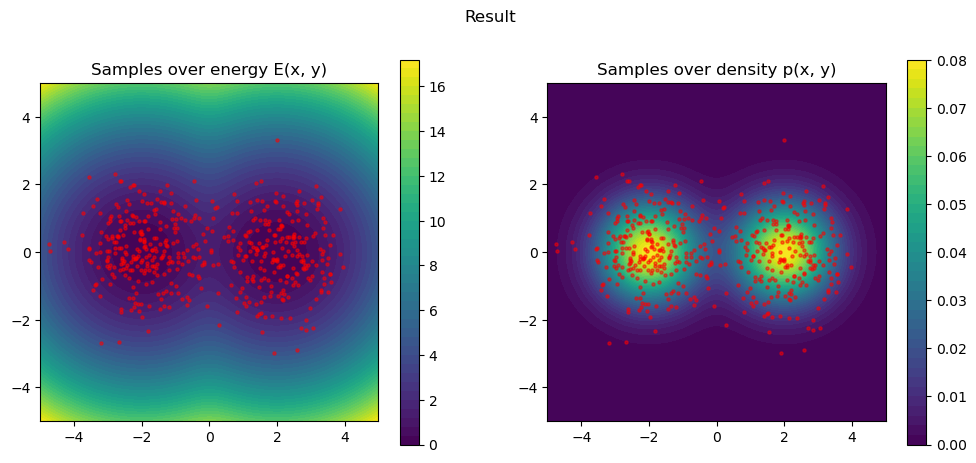

In [12]:
# task 8.1.2

def plot(x_samples, energy_fn, density_fn, title="Result"):
    grid_size = 200
    x_min, x_max = -5, 5
    y_min, y_max = -5, 5

    xs = torch.linspace(x_min, x_max, grid_size)
    ys = torch.linspace(y_min, y_max, grid_size)
    xx, yy = torch.meshgrid(xs, ys, indexing="xy")

    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

    with torch.no_grad():
        E_grid = energy_fn(grid).reshape(grid_size, grid_size)
        p_grid = density_fn(grid).reshape(grid_size, grid_size)

    samples = x_samples.detach().cpu().numpy()


    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1) samples over energy contours
    # TODO: plot energy contours and samples
    cs0 = axes[0].contourf(xx.numpy(), yy.numpy(), E_grid.numpy(), levels=50, cmap="viridis")
    fig.colorbar(cs0, ax=axes[0])
    axes[0].scatter(samples[:, 0], samples[:, 1], s=5, c="red", alpha=0.5)
    axes[0].set_title("Samples over energy E(x, y)")
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[0].set_aspect("equal")

    # 2) samples over true density
    # TODO: plot density contours and samples
    cs1 = axes[1].contourf(xx.numpy(), yy.numpy(), p_grid.numpy(), levels=50, cmap="viridis")
    fig.colorbar(cs1, ax=axes[1])
    axes[1].scatter(samples[:, 0], samples[:, 1], s=5, c="red", alpha=0.5)
    axes[1].set_title("Samples over density p(x, y)")
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    axes[1].set_aspect("equal")

    fig.suptitle(title)

    plt.show()

plot(x_samples, energy, density)

**Observation**: The samples concentrate in the two regions of low energy / high density around the modes $(-2, 0)$ and $(2, 0)$, matching the two Gaussian bumps of the target distribution. Few samples lie in the high-energy valley between the modes, and the density of points roughly mirrors the shape of $p(x, y)$. Starting from $\mathcal{N}(0, I)$ the points get pulled along the score towards both modes and end up split between them, while the injected noise keeps them spread out within each mode instead of collapsing to a single point.

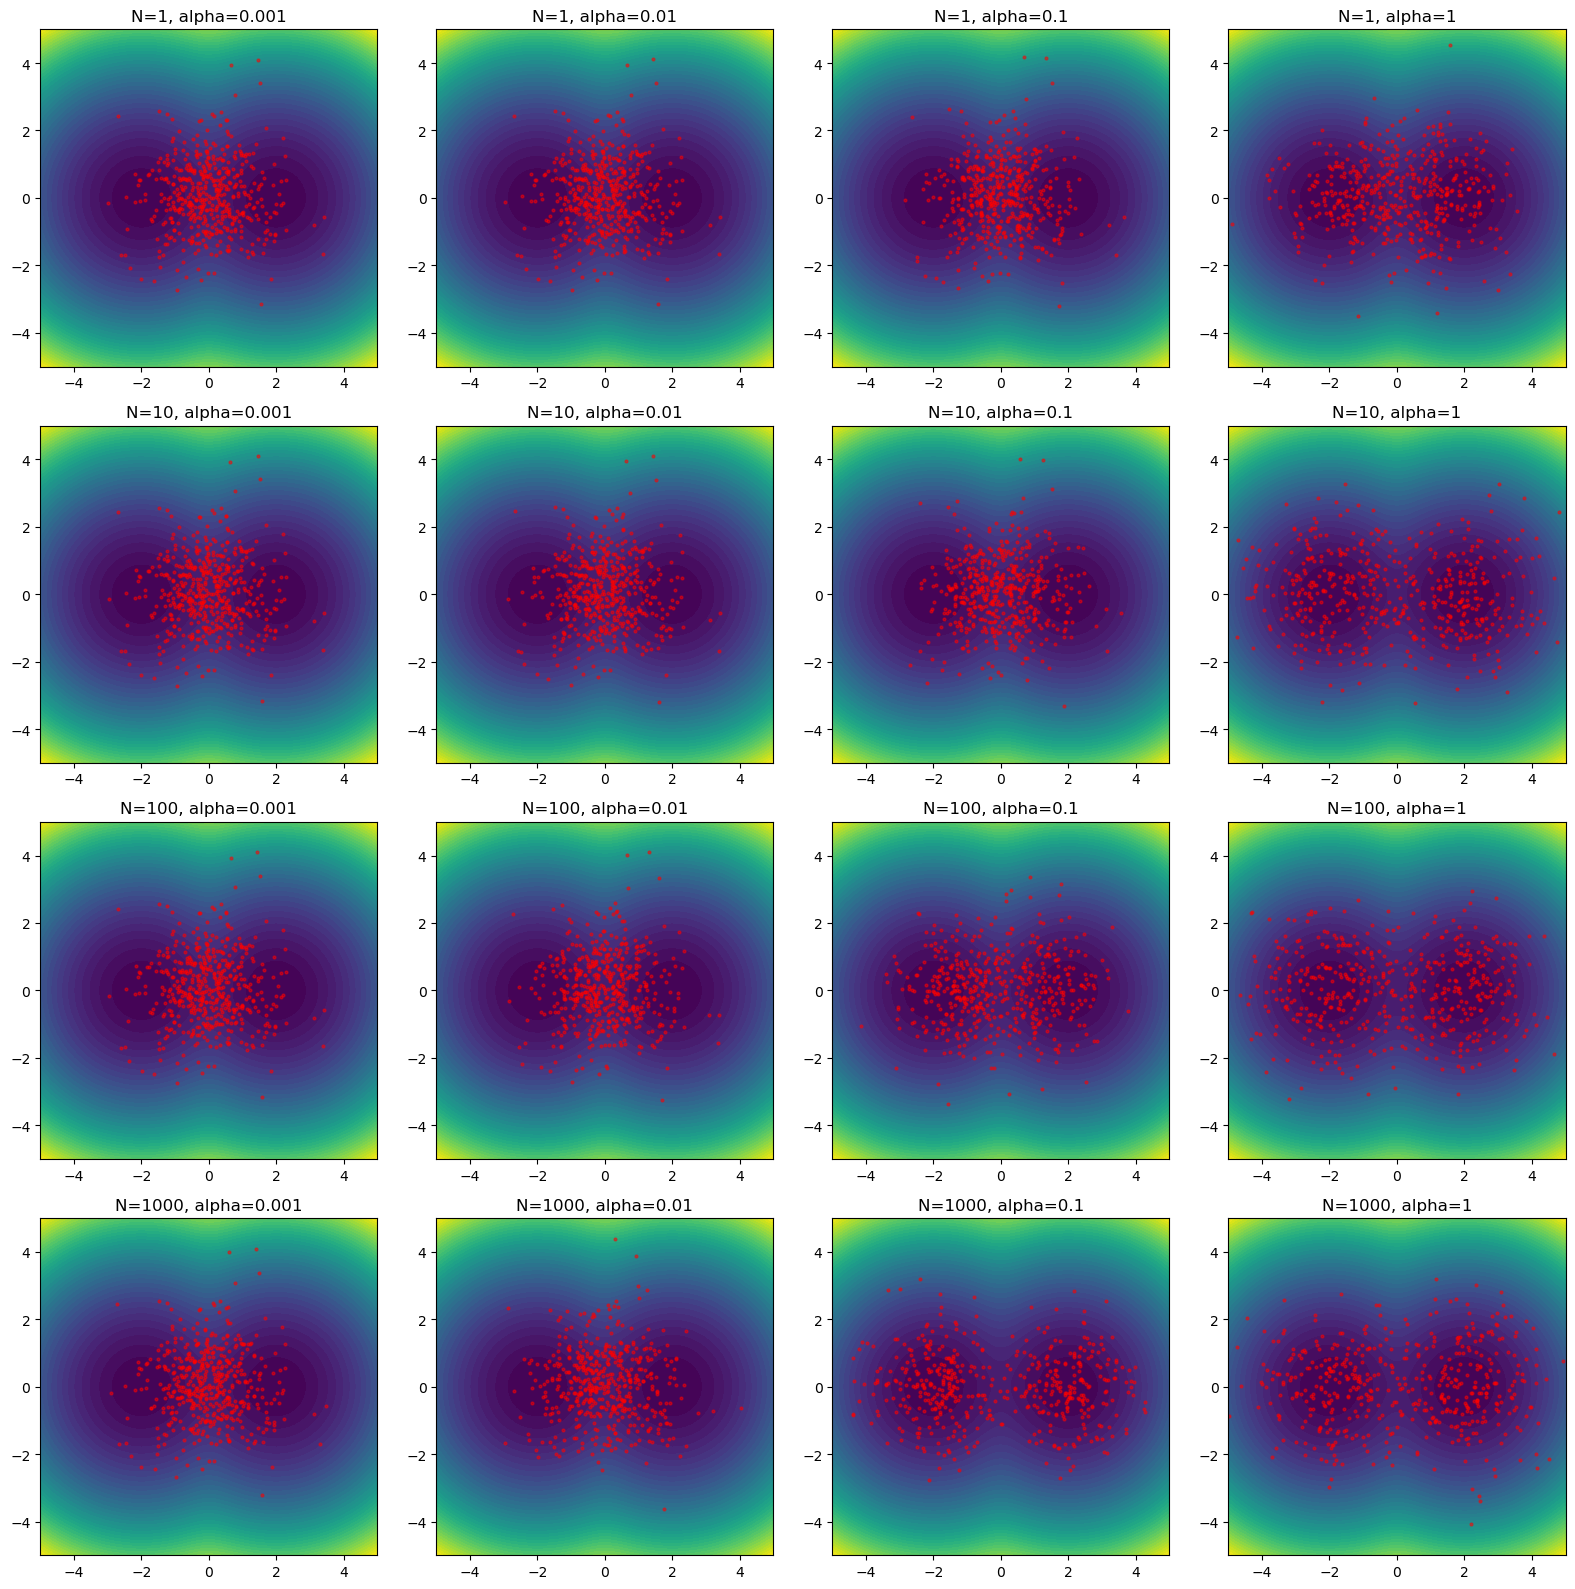

In [13]:
# task 8.1.3

# TODO:
steps_list = [1, 10, 100, 1000]
alpha_list = [0.001, 0.01, 0.1, 1]

# precompute energy grid for the background contours
grid_size = 200
x_min, x_max, y_min, y_max = -5, 5, -5, 5
xs = torch.linspace(x_min, x_max, grid_size)
ys = torch.linspace(y_min, y_max, grid_size)
xx, yy = torch.meshgrid(xs, ys, indexing="xy")
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
with torch.no_grad():
    E_grid = energy(grid).reshape(grid_size, grid_size)

fig, axes = plt.subplots(len(steps_list), len(alpha_list),
                         figsize=(4 * len(alpha_list), 4 * len(steps_list)))

for i, n_steps in enumerate(steps_list):
    for j, alpha in enumerate(alpha_list):
        torch.manual_seed(0)
        x0 = torch.randn(500, 2)
        samples = langevin_sampling(x0, n_steps=n_steps, step_size=alpha).detach().cpu().numpy()

        ax = axes[i, j]
        ax.contourf(xx.numpy(), yy.numpy(), E_grid.numpy(), levels=50, cmap="viridis")
        ax.scatter(samples[:, 0], samples[:, 1], s=4, c="red", alpha=0.5)
        ax.set_title(f"N={n_steps}, alpha={alpha}")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect("equal")

plt.tight_layout()
plt.show()

**Observations**:

Both the number of steps $N$ and the step size $\alpha$ control how far the chain travels and how well it mixes. The effective drift/noise per step scales with $\alpha$ (drift $\propto \alpha^2/2$, noise $\propto \alpha$), so the total progress depends on the combination of $N$ and $\alpha$.

- **Small $\alpha$ (0.001, 0.01):** each update barely moves the points. Even with $N=1000$ steps the samples stay close to the initial $\mathcal{N}(0, I)$ cloud near the origin and never reach the two modes. The chain is far from converged.
- **Moderate $\alpha = 0.1$:** with enough steps ($N=100$–$1000$) the samples cleanly converge onto the two modes at $(\pm 2, 0)$, reproducing the target density. With few steps ($N=1$–$10$) they have only partially moved towards the modes.
- **Large $\alpha = 1$:** the steps are too big. The strong noise term ($\alpha \mathbf{z}$) and large drift overshoot the modes, producing a wide, diffuse spread of points that does not match the target — the discretization of Langevin dynamics breaks down (large step-size bias).
- **Steps $N$:** more steps generally give more time to converge, but only help if $\alpha$ is in a usable range. Too few steps means the chain has not yet reached the stationary distribution; too many steps with a good $\alpha$ simply maintains the converged distribution.

In short: $\alpha$ must be large enough to move but small enough to stay accurate, and $N$ must be large enough for the chain to converge. The pair $N=1000, \alpha=0.1$ gives the best match to the true density.

**Task d)**:

**Why do samples accumulate in low-energy regions?**
The deterministic part of the Langevin update is a gradient-ascent step on the log-density: $-\frac{\alpha^2}{2}\nabla_x E(x) = \frac{\alpha^2}{2}\nabla_x \log p(x)$. The score $-\nabla_x E$ points towards regions of lower energy, i.e. higher probability, so each step pushes a sample "downhill" in energy / "uphill" in density. Once a sample reaches a low-energy basin, the gradient there is small and the drift keeps it nearby, so the chain spends most of its time where $E$ is low. More formally, Langevin dynamics has $p(x) \propto e^{-E(x)}$ as its stationary distribution, and that distribution places the most mass exactly where the energy is lowest — hence samples accumulate there.

**Why do we need to add noise?**
Without the noise term $\alpha \mathbf{z}$ the update is pure gradient descent on the energy: every point would deterministically slide to the nearest local minimum and collapse onto a single point (the mode), giving zero variance and ignoring the spread of $p(x)$. We would only ever recover modes, not samples from the distribution. The injected Gaussian noise lets the chain explore, occasionally move uphill in probability, escape/cross between basins (e.g. visit both modes at $\pm 2$), and ultimately makes $p(x) \propto e^{-E(x)}$ the stationary distribution of the chain rather than a point mass at the minimum. In other words, the noise is what turns gradient descent (mode-seeking) into proper sampling that reproduces the full density.

## Task 8.2: Training an EBM Denoiser (8P)

**Background.**

For more complex data, we have to learn the energy model $E_\theta(\mathbf{x})$.
In a perfect world we want our model to optimize

$$
\max_\theta \mathbb{E}_{\mathbf{x} \sim p_{data}} [\log p_\theta(\mathbf{x})]
$$

but the ground truth distribution is unknown. We can reformulate to obtain

$$
\nabla_\theta \log p_\theta(\mathbf{x})
=
- \nabla_\theta E_\theta(\mathbf{x})
-
\nabla_\theta \log Z(\theta).
$$

The second term can be rewritten as

$$
\nabla_\theta \log Z(\theta)
=
\mathbb{E}_{\mathbf{x}\sim p_\theta}
[-\nabla_\theta E_\theta(\mathbf{x})].
$$

This is convenient because we have already seen how we can sample from $p_\theta$. Therefore, maximizing the log-likelihood consists of two competing objectives:

1. decrease the energy of real samples,
2. increase the energy of samples produced by Langevin dynamics with the current model.

Putting the loss together we get

$$
\nabla_\theta \log p_\theta(\mathbf{x})
\approx
-
\nabla_\theta E_\theta(\mathbf{x})
+
\nabla_\theta E_\theta(\mathbf{\tilde x}),
\qquad
\mathbf{\tilde x} \sim p_\theta.
$$

Because sampling good $\mathbf{\tilde x}$ from scratch is slow, [contrastive divergence](https://www.cs.toronto.edu/~hinton/absps/tr00-004.pdf) instead proposes to initialize Langevin dynamics from a noisy version of a real data sample and perform only a small number of Langevin updates.

**Task.**

1. **(3P)** Implement an energy model consisting of a 3-layer CNN with MaxPooling followed by a 2-layer MLP that outputs a scalar energy. Then implement Langevin dynamics for this model by computing the score via automatic differentiation using `torch.autograd.grad(energy, x)[0]`. The sampler should start from an initial image and perform several Langevin updates while keeping pixel values in the valid range.

2. **(3P)** Train the energy model on the MNIST dataset using contrastive divergence. Initialize the negative samples with a noisy version of each training image ($\sigma^2 = 0.3$) and refine them using the Langevin sampler from part (a). Perform 30 sampling steps with $\alpha = 0.2$ and noise scale $0.01$. Optimize the contrastive divergence objective with the Adam optimizer for 5000 training steps. Add an $L_2$ regularization term on the predicted energies to prevent the energy values from diverging. Visualize the provided real, noisy and denoised samples every 1000 training steps.

3. **(2P)** Evaluate your trained EBM using the relative log-probability equation from the lecture. Compare the average relative log probabilities and average relative probabilities of (1) random noise, (2) noisy images, (3) denoised images obtained with Langevin dynamics, and (4) ground truth images over 1000 samples. Note down your observations and explain why machine learning papers typically report log probabilities (or log-likelihoods) instead of probabilities.

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = T.Compose([
    T.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

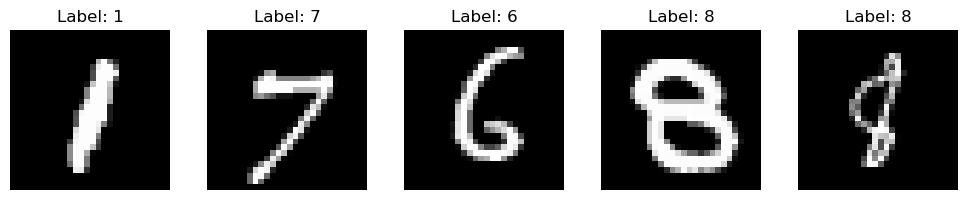

In [15]:
def plot_samples(loader, n=5):
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    for i in range(n):
        axes[i].imshow(images[i, 0], cmap="gray")
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

plot_samples(loader)

In [16]:
# Task 8.2.1

class CNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        num_groups = min(32, in_channels)

        self.norm = nn.GroupNorm(num_groups, in_channels)

        # TODO: implement a convolutional layer with ReLU and 2x2 max pooling
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.norm(x)
        # TODO finalize the forward pass
        x = self.conv(x)
        x = self.act(x)
        x = self.pool(x)
        return x

class EnergyCNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # TODO: construct the feedforward CNN architecture
            # 3-layer CNN with MaxPooling: 28 -> 14 -> 7 -> 3
            CNNLayer(1, 16),
            CNNLayer(16, 32),
            CNNLayer(32, 64),
            # followed by a 2-layer MLP that outputs a scalar energy
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = EnergyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [17]:
def langevin_sample_cnn(model, x, n_steps=30, step_size=0.1, noise_scale=0.01):
    # Tip: take inspiration from the previous langevin_sampling function, but now use the model to compute the score
    # there is an additional noise_scale parameter here, add the noise as follows: x = x + noise_scale * torch.randn_like(x)
    x = x.clone().detach().requires_grad_(True)
    # TODO: implement Langevin sampling using the CNN model, (use: torch.autograd.grad(energy, x)[0])
    for _ in range(n_steps):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x)[0]
        # move towards lower energy (= higher probability) and add exploration noise
        x = x - step_size * grad + noise_scale * torch.randn_like(x)
        # keep pixel values in the valid range
        x = x.clamp(0.0, 1.0)
        x = x.detach().requires_grad_(True)
    return x.detach()

In [18]:
def visualize_samples(model, real, n=8):
    real = real[:n].to(device)
    noisy = (real + 0.3 * torch.randn_like(real)).clamp(0.0, 1.0)

    denoised = langevin_sample_cnn(
        model,
        noisy,
        n_steps=500,
        step_size=0.01,
        noise_scale=0.001,
    )

    fig, axes = plt.subplots(3, n, figsize=(1.5 * n, 3.5))
    for i in range(n):
        axes[0, i].imshow(real[i, 0].cpu(), cmap="gray")
        axes[1, i].imshow(noisy[i, 0].cpu(), cmap="gray")
        axes[2, i].imshow(denoised[i, 0].cpu(), cmap="gray")
        for j in range(3):
            axes[j, i].axis("off")

    # Row labels
    fig.text(0.04, 0.83, "Real",      rotation=90, va="center", ha="center", fontsize=12)
    fig.text(0.04, 0.50, "Noisy",     rotation=90, va="center", ha="center", fontsize=12)
    fig.text(0.04, 0.17, "Denoised",  rotation=90, va="center", ha="center", fontsize=12)
    plt.tight_layout(rect=[0.05, 0, 1, 1])
    plt.show()

Step 100, Loss: -0.1586, E(real)=-1.9505, E(fake)=-1.7847
Step 200, Loss: -0.2548, E(real)=-6.0378, E(fake)=-5.7125
Step 300, Loss: -6.2046, E(real)=-18.6990, E(fake)=-11.9813
Step 400, Loss: -176.1923, E(real)=-196.6923, E(fake)=19.4918
Step 500, Loss: -360.4345, E(real)=-462.4369, E(fake)=132.0464
Step 600, Loss: -488.9091, E(real)=-485.4261, E(fake)=435.7214
Step 700, Loss: -492.9182, E(real)=-486.5223, E(fake)=470.8368
Step 800, Loss: -495.2505, E(real)=-497.8826, E(fake)=493.8309
Step 900, Loss: -496.1071, E(real)=-496.7713, E(fake)=484.4034
Step 1000, Loss: -496.8353, E(real)=-496.1776, E(fake)=487.7808


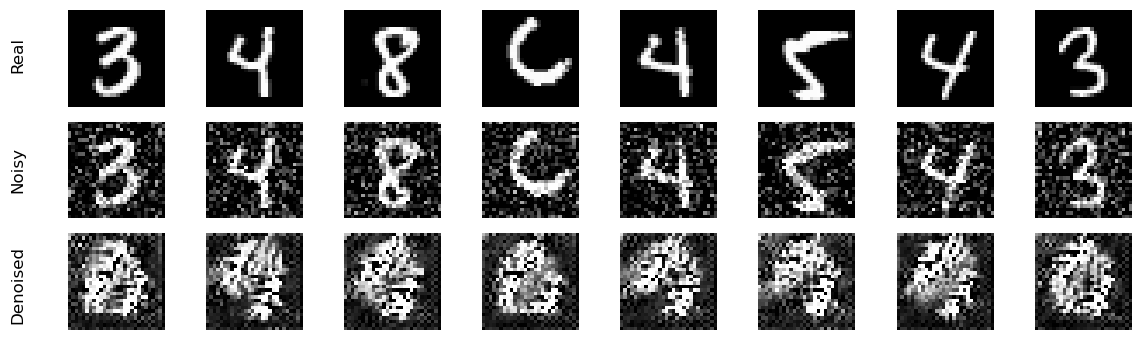

Step 1100, Loss: -496.8581, E(real)=-496.1022, E(fake)=489.9609
Step 1200, Loss: -497.5959, E(real)=-500.0167, E(fake)=495.0312
Step 1300, Loss: -497.2188, E(real)=-496.5707, E(fake)=491.4366
Step 1400, Loss: -497.7665, E(real)=-496.8832, E(fake)=498.2430
Step 1500, Loss: -498.0066, E(real)=-498.4438, E(fake)=498.2402
Step 1600, Loss: -498.0729, E(real)=-501.0869, E(fake)=491.6599
Step 1700, Loss: -498.4318, E(real)=-498.8501, E(fake)=490.8023
Step 1800, Loss: -498.5106, E(real)=-499.0433, E(fake)=497.3154
Step 1900, Loss: -498.6342, E(real)=-500.1477, E(fake)=493.7800
Step 2000, Loss: -498.8393, E(real)=-501.6767, E(fake)=499.7981


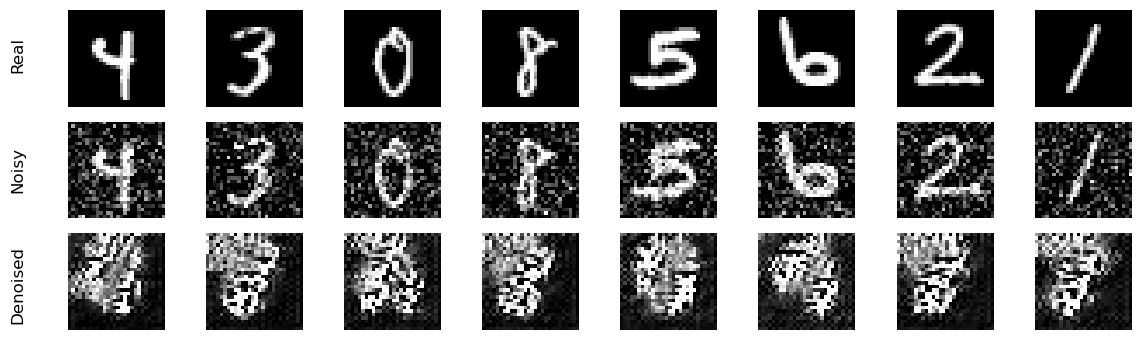

Step 2100, Loss: -498.8770, E(real)=-497.3300, E(fake)=501.3328
Step 2200, Loss: -499.0367, E(real)=-502.4870, E(fake)=497.2312
Step 2300, Loss: -499.1098, E(real)=-496.6713, E(fake)=501.5098
Step 2400, Loss: -499.2491, E(real)=-501.4902, E(fake)=500.7411
Step 2500, Loss: -499.0652, E(real)=-494.5429, E(fake)=500.6196
Step 2600, Loss: -499.0446, E(real)=-498.3198, E(fake)=501.8615
Step 2700, Loss: -499.1706, E(real)=-501.5095, E(fake)=498.1433
Step 2800, Loss: -499.2264, E(real)=-500.5434, E(fake)=497.1181
Step 2900, Loss: -499.2174, E(real)=-500.3926, E(fake)=500.9843
Step 3000, Loss: -499.2629, E(real)=-499.2075, E(fake)=498.8402


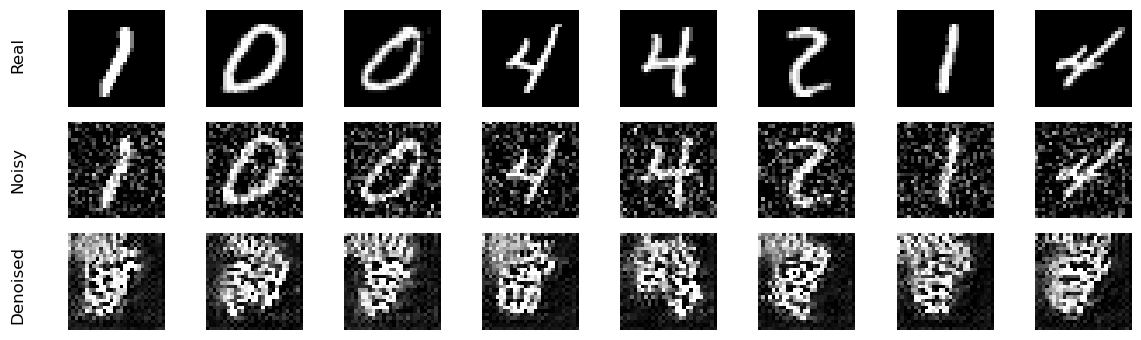

Step 3100, Loss: -499.2966, E(real)=-499.8932, E(fake)=497.0888
Step 3200, Loss: -499.4146, E(real)=-499.6134, E(fake)=498.9794
Step 3300, Loss: -499.3203, E(real)=-497.5650, E(fake)=496.9649
Step 3400, Loss: -499.4323, E(real)=-498.6417, E(fake)=501.3831
Step 3500, Loss: -499.4263, E(real)=-501.0374, E(fake)=499.1150
Step 3600, Loss: -499.4424, E(real)=-497.7499, E(fake)=497.9411
Step 3700, Loss: -499.4624, E(real)=-501.3448, E(fake)=498.9860
Step 3800, Loss: -499.4279, E(real)=-497.1314, E(fake)=496.3441
Step 3900, Loss: -499.4337, E(real)=-496.8073, E(fake)=498.5717
Step 4000, Loss: -499.5937, E(real)=-501.6407, E(fake)=500.4503


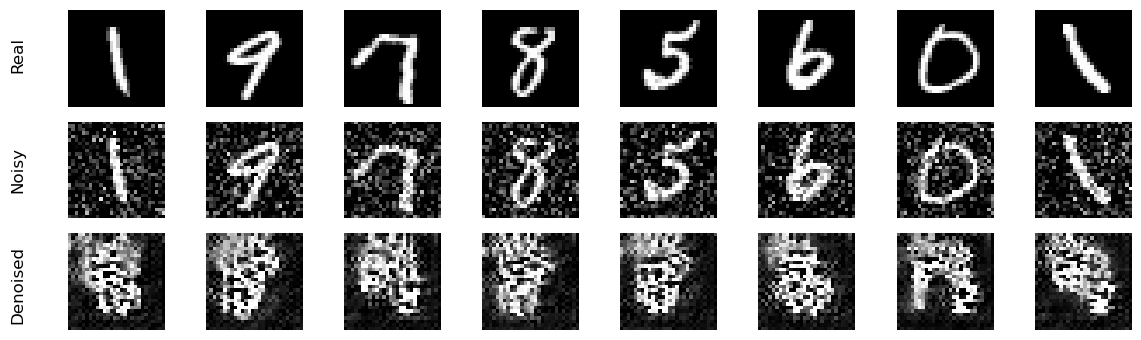

Step 4100, Loss: -499.5812, E(real)=-502.4291, E(fake)=502.1143
Step 4200, Loss: -499.5964, E(real)=-497.6278, E(fake)=500.3760
Step 4300, Loss: -499.5584, E(real)=-499.0190, E(fake)=498.2969
Step 4400, Loss: -499.5974, E(real)=-499.1444, E(fake)=497.7699
Step 4500, Loss: -499.5551, E(real)=-501.0750, E(fake)=496.3580
Step 4600, Loss: -499.5417, E(real)=-502.4362, E(fake)=499.9770
Step 4700, Loss: -499.5863, E(real)=-498.6838, E(fake)=498.8879
Step 4800, Loss: -499.6881, E(real)=-500.9637, E(fake)=498.3528
Step 4900, Loss: -499.6769, E(real)=-499.2277, E(fake)=499.7739
Step 5000, Loss: -499.6956, E(real)=-501.5142, E(fake)=498.4755


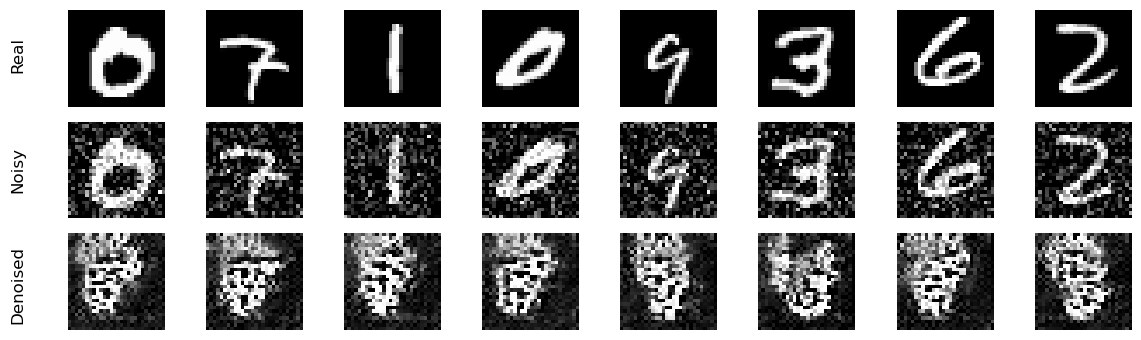

Finished 🎉


In [19]:
# task 8.2.2

n_steps = 5_000
reg_weight = 0.001

step = 0
while step < n_steps:
    for real, _ in loader:
        if step >= n_steps:
            print("Finished 🎉")
            break

        real = real.to(device)

        # TODO: obtain fake samples following contrastive divergence
        # initialize negative samples with a noisy version of the real images (sigma^2 = 0.3)
        noisy = (real + math.sqrt(0.3) * torch.randn_like(real)).clamp(0.0, 1.0)
        # refine them with a few Langevin steps using the current model
        fake = langevin_sample_cnn(model, noisy, n_steps=30, step_size=0.2, noise_scale=0.01)

        real_energy = model(real)
        fake_energy = model(fake)

        # TODO: implement contrastive divergence loss
        # decrease energy of real samples, increase energy of fake samples
        cd_loss = real_energy.mean() - fake_energy.mean()

        reg_loss = real_energy.pow(2).mean() + fake_energy.pow(2).mean()
        loss = cd_loss + reg_weight * reg_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        step += 1

        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss.item():.4f}, E(real)={real_energy.mean().item():.4f}, E(fake)={fake_energy.mean().item():.4f}")
        if step % 1000 == 0:
            visualize_samples(model, real)

In [20]:
# task 8.2.3

def compare_relative_log_probs(model, loader, n_samples=100) -> dict[str, float]:
    # TODO: implement a function that compares the relative log probabilities of real vs fake samples using the trained model, for denoising use 500 steps, step_size 0.01, and noise_scale 0.001
    was_training = model.training
    model.eval()

    # collect n_samples real images
    reals = []
    collected = 0
    for real, _ in loader:
        reals.append(real)
        collected += real.size(0)
        if collected >= n_samples:
            break
    real = torch.cat(reals, dim=0)[:n_samples].to(device)

    # the four image categories
    random_noise = torch.rand_like(real)                                   # uniform noise in valid range
    noisy = (real + 0.3 * torch.randn_like(real)).clamp(0.0, 1.0)          # noisy images
    denoised = langevin_sample_cnn(model, noisy, n_steps=500, step_size=0.01, noise_scale=0.001)

    with torch.no_grad():
        e_real = model(real).mean()
        e_random = model(random_noise).mean()
        e_noisy = model(noisy).mean()
        e_denoised = model(denoised).mean()

    # log p(x) = -E(x) - log Z. Relative to real the (intractable) log Z cancels:
    # log p(x) - log p(real) = E(real) - E(x)
    results = {
        "random_noise": (e_real - e_random).item(),
        "noisy":        (e_real - e_noisy).item(),
        "denoised":     (e_real - e_denoised).item(),
        "ground_truth": (e_real - e_real).item(),  # reference, = 0
    }

    if was_training:
        model.train()
    return results

rel_prob_results = compare_relative_log_probs(model, loader, n_samples=1000)
print("Relative log probabilities (compared to real):")
for k, v in rel_prob_results.items():
    print(f"{k}: {v:.4f}")

print("Relative probabilities (compared to real):")
for k, v in rel_prob_results.items():
    print(f"{k}: {math.exp(v):.4f}")

Relative log probabilities (compared to real):
random_noise: -982.7625
noisy: -289.9661
denoised: -104.9489
ground_truth: 0.0000
Relative probabilities (compared to real):
random_noise: 0.0000
noisy: 0.0000
denoised: 0.0000
ground_truth: 1.0000


**Observations:**

We report log-probabilities *relative* to real images, i.e. $\log p(x) - \log p(x_{\text{real}}) = E(x_{\text{real}}) - E(x)$, which lets the intractable normalizing constant $\log Z$ cancel out. By construction the ground-truth value is $0$.

The expected ordering (most to least probable under the model) is:

$$\text{ground truth} \gtrsim \text{denoised} > \text{noisy} \gg \text{random noise}.$$

- **Random noise** has by far the lowest relative log-probability (large negative value): it lies completely off the data manifold, so the model assigns it very high energy.
- **Noisy images** are corrupted versions of real digits and sit between noise and real — recognizable but penalized for the added noise.
- **Denoised images** (Langevin-refined) move back towards low energy, so their relative log-probability is close to that of real images and clearly higher than the noisy inputs they started from. This confirms the sampler successfully pushes samples into high-probability regions learned by the EBM.
- **Ground truth** is the reference ($0$).

**Why report log-probabilities instead of probabilities?**

1. **Numerical range / underflow.** Probabilities of high-dimensional data are astronomically small (e.g. $e^{-300}$) and underflow to $0$ in floating point, whereas their logs stay in a comfortable range. The "relative probabilities" column ($\exp$ of the log values) makes this obvious: for random noise it collapses to essentially $0$, losing all resolution, while the log values remain informative and comparable.
2. **The normalizing constant.** $\log Z$ is intractable, but in log-space it appears as an additive constant that cancels when taking *differences* of log-probabilities — so relative log-probabilities are computable while absolute probabilities are not.
3. **Additivity & optimization.** Log-likelihoods of independent samples add instead of multiply, giving numerically stable training objectives and gradients (log-likelihood maximization).

# Task 8.3: Score Matching (7P)

**Background.**

In Energy-based Modeling we approximate the score $\nabla_\mathbf{x} \log p(\mathbf{x})$ using gradients on the unnormalized energy. Score matching proposes to instead learn the score

$$
s_\theta(\mathbf{x}) \approx \nabla_\mathbf{x} \log p(\mathbf{x})
$$

directly. However, the true score $\nabla_\mathbf{x} \log p(\mathbf{x})$ is unknown, making direct supervision tricky. 

Denoising Score Matching presents an alternative where we learn to instead approximate the conditional score
$$
s_\theta(\mathbf{x}_t) = \nabla_{\mathbf{x}_t} \log q(\mathbf{x}_t | \mathbf{x}, \sigma_t^2 I)
$$
where $q(\mathbf{x}_t | \mathbf{x}, \sigma_t^2 I)$ is a Gaussian distribution centered at $\mathbf{x}$ with variance $\sigma^2$.

Given a data sample $\mathbf{x}$ we can sample from the conditional distribution

$$
q(\mathbf{x}_t \mid \mathbf{x}, \sigma_t^2 I)
=
\mathcal{N}(\mathbf{x}_t \mid \mathbf{x}, \sigma_t^2 I)
$$

using the reparametrization trick:

$$
\mathbf{x}_t
=
\mathbf{x}
+
\sigma_t \epsilon
\sim
\mathcal{N}(\mathbf{x}_t \mid \mathbf{x}, \sigma_t^2 I),
\qquad
\epsilon \sim \mathcal{N}(0, I).
$$

Given $\mathbf{x}$, the conditional score has a simple closed-form solution

$$
\nabla_{\mathbf{x}_t}
\log
\mathcal{N}(\mathbf{x}_t \mid \mathbf{x}, \sigma_t^2 I)
=
\frac{\mathbf{x}-\mathbf{x}_t}{\sigma_t^2},
$$

which we can use to supervise $s_\theta(\mathbf{x}_t, \sigma_t)$.

**Task.**

1. **(2P)** Mathematically derive the closed-form conditional score above starting from the definition of $q(\mathbf{x}_t | \mathbf{x}, \sigma_t^2 I)$. Give all your steps, as they will be considered for grading!

2. **(4P)** Train a denoising score model. Implement $s_\theta(x_t, \sigma_t)$ as a small convolutional [U-Net](https://arxiv.org/abs/1505.04597) (most of the implementation is already provided but you have to fill in some parts of the forward pass) and train it to predict the score of noisy MNIST images using an Adam optimizer for at least 10k iterations (better 50k). During training, randomly sample the noise level $\sigma$ from a uniform distribution

   $$
   \sigma \sim \mathcal{U}(0.01, 2).
   $$

   Normalize your MNIST images to the range $[-1, 1]$ before applying noise (don't forget to unnormalize the generated samples for visualization). Condition your model on the current noise level. Use the provided sigma embedding, learn a projection of the embedding for each U-Net resolution, and add the projected embedding to the corresponding feature maps. Train the model with an MSE objective between the predicted score and the ground-truth conditional score derived above. Weight the MSE by the current noise level $\sigma_t^2$.

3. **(1P)** Sample 10 generations from your model using Langevin dynamics starting from Gaussian noise and the predicted score. Use 50 equally spaced and decreasing noise levels between $\sigma=2$ and $\sigma=0.01$. Perform 20 Langevin updates for each noise level. For each update use

   $$
   \alpha = \beta \left(\frac{\sigma}{\sigma_{\max}}\right)^2,
   \qquad
   \beta = 0.00002.
   $$

   Visualize the generated samples.

**Task 8.3.1**

`TODO`

In [ ]:
# Task 8.3.2

device = "cuda" if torch.cuda.is_available() else "cpu"

def sigma_embedding(sigma, dim=64):
    sigma = sigma.view(-1, 1)
    log_sigma = torch.log(sigma)
    half = dim // 2
    freqs = torch.exp(
        torch.linspace(0, math.log(10000), half, device=sigma.device)
    )
    emb = log_sigma / freqs
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb

class ConvBlock(nn.Module):

    def __init__(self, in_ch, out_ch, emb_dim=64):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.act1 = nn.ReLU()
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act2 = nn.ReLU()
        self.emb_proj = nn.Linear(emb_dim, out_ch)

    def forward(self, x, emb):
        h = x
        # TODO: implement forward pass: 1) conv + act, 2) add projected embedding, 3) conv + act
        return h

class ScoreUnet(nn.Module):

    def __init__(self, num_bottleneck_layers: int=3, num_down_levels: int=2, emb_dim=64):
        super().__init__()
        self.emb_dim = emb_dim

        self.in_conv = nn.Conv2d(1, 32, 3, padding=1)
        self.in_act = nn.ReLU()

        c_channels = 32
        skip_channels = []

        self.down_levels = nn.ModuleList()
        for _ in range(num_down_levels):
            out_channels = c_channels * 2
            self.down_levels.append(ConvBlock(c_channels, out_channels, emb_dim))
            self.down_levels.append(nn.MaxPool2d(2))
            c_channels = out_channels
            skip_channels.append(c_channels)

        self.bottleneck = nn.ModuleList()
        for _ in range(num_bottleneck_layers):
            self.bottleneck.append(ConvBlock(c_channels, c_channels, emb_dim))
        
        self.up_levels = nn.ModuleList()
        for _ in range(num_down_levels):
            out_channels = c_channels // 2
            skip_c = skip_channels.pop()
            self.up_levels.append(nn.ConvTranspose2d(c_channels, out_channels, 2, stride=2))
            self.up_levels.append(ConvBlock(out_channels + skip_c, out_channels, emb_dim))
            c_channels = out_channels

        self.out_conv = nn.Conv2d(c_channels, 1, 3, padding=1)

    def forward(self, x, sigma):
        emb = sigma_embedding(sigma, self.emb_dim)

        h = self.in_act(self.in_conv(x))
        skip_connections = []
        for layer in self.down_levels:
            # TODO: forward pass through down levels. NOTE: for each ConvBlock save the skip connection (features before applying the pooling)
            pass

        for layer in self.bottleneck:
            # TODO: forward pass through bottleneck layers
            pass

        for layer in self.up_levels:
            # TODO: forward pass through up levels. NOTE: for each ConvBlock concatenate the skip connection (from the corresponding down level) to the input features
            pass

        return self.out_conv(h)

model = ScoreUnet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
n_steps = 50_000    # reduce steps if your compute resources are limited but expect lower sample quality. Try to perform as many training steps as possible, models can take time to coverge.
step = 0

transform = T.Compose([
    T.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

while step < n_steps:
    for x, _ in loader:
        if step >= n_steps:
            break

        x = x.to(device)
        x = 2 * x - 1  # scale to [-1, 1]
        # TODO: sample sigma

        # TODO: create x_t

        # GT score
        # TODO: calculate target score

        # predicted score
        # TODO: get predicted score

        # weighted MSE loss
        # TODO: calculate the weighted MSE loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step += 1

        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss.item():.4f}")

print("Finished 🎉")

In [ ]:
# Task 8.3.3

@torch.no_grad()
def sample_score_model(model, n_samples=10, image_shape=(1, 28, 28), steps: int=50, steps_for_sigma: int=20, step_lr: float=0.00002):
    is_training = model.training
    model.eval()
    
    sigmas = None # TODO: setup sigmas

    x = sigmas[0] * torch.randn(n_samples, *image_shape, device=sigmas.device)

    for sigma in sigmas:
        sigma_batch = torch.full((n_samples,), sigma.item(), device=sigma.device)

        alpha = step_lr * (sigma / sigmas[-1]) ** 2

        for _ in range(steps_for_sigma):
            # TODO: implement the Langevin dynamics sampling step using the score model
            pass

    if is_training:
        model.train()
    return ((x + 1) / 2).clamp(0, 1).cpu()  # scale back to [0, 1]

def visualize_generated_samples(model, n_samples=10):
    samples = sample_score_model(
        model,
        n_samples=n_samples,
        steps=50,
        steps_for_sigma=30,
        step_lr=0.00002,
    )

    fig, axes = plt.subplots(1, n_samples, figsize=(1.5 * n_samples, 1.8))

    for i in range(n_samples):
        axes[i].imshow(samples[i, 0], cmap="gray")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

visualize_generated_samples(model, n_samples=10)